In [36]:
import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import numpy as np
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    log_loss
)


In [37]:
load_dotenv()
engine = create_engine(os.getenv("SUPABASE_DB_URL"))

query = "SELECT * FROM weather_logs_features_test ;"
df = pd.read_sql(query, con=engine)
df.tail()

,temperature_2m_mean,temperature_2m_min,temperature_2m_max,relative_humidity_2m_mean,relative_humidity_2m_max,rain_sum,surface_pressure_mean,surface_pressure_min,surface_pressure_max,precipitation_sum,...,surface_pressure_mean_rolling_mean_7d,precipitation_sum_rolling_mean_3d,precipitation_sum_rolling_mean_7d,cloud_cover_mean_rolling_mean_3d,cloud_cover_mean_rolling_mean_7d,precipitation_sum_rolling_3d,precipitation_sum_rolling_7d,pressure_change_1d,pressure_change_3d,temperature_change_1d
122,21.661667,17.32,26.92,40.500000,64.0,0.0,1001.909583,999.90,1005.03,0.0,...,1005.136654,0.0,1.614286,27.333333,49.538561,0.0,11.3,1.701250,-5.057500,0.445833
123,21.932500,16.17,27.87,39.958333,54.0,0.0,1008.404167,1005.50,1010.09,0.0,...,1004.787070,0.0,0.185714,48.458333,46.330228,0.0,1.3,6.494583,6.185000,0.270833
124,22.865833,16.27,28.72,39.458333,57.0,0.0,1008.554167,1005.40,1010.98,0.0,...,1004.878082,0.0,0.185714,49.013889,42.449275,0.0,1.3,0.150000,8.345833,0.933333
125,18.215652,14.57,22.22,49.913043,72.0,0.0,1007.946522,1005.52,1009.64,0.0,...,1005.025761,0.0,0.185714,50.791667,45.407609,0.0,1.3,-0.607645,6.036938,-4.650181
126,14.701250,11.87,19.57,61.250000,78.0,0.1,1007.660833,1006.66,1009.23,0.1,...,1005.172717,0.0,0.000000,39.109300,39.034938,0.0,0.0,-0.285688,-0.743333,-3.514402


In [38]:
# ============================================================
# TARGET ÉS FEATURES
# ============================================================

y = df["target_rain_next_day"]

drop_cols = [
    # Target
    "target_rain_next_day",

    # FUTURE LEAKAGE
    # Ez a következő 24 órából származó információ.
    "rain_sum_next_24h",

    # Timestampet nem adunk közvetlenül az XGBoostnak.
    "timestamp",

    # Az eredeti szélirány helyett sin/cos encodingot használunk.
    "wind_direction_10m",

    # Ezekből már létrehoztunk jobb változatokat,
    # ezért az eredetit elhagyjuk.
    "hour",
    "day",
]


X = df.drop(
    columns=[
        col
        for col in drop_cols
        if col in df.columns
    ]
)


print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

X shape: (127, 63)
y shape: (127,)

Features:
['temperature_2m_mean', 'temperature_2m_min', 'temperature_2m_max', 'relative_humidity_2m_mean', 'relative_humidity_2m_max', 'rain_sum', 'surface_pressure_mean', 'surface_pressure_min', 'surface_pressure_max', 'precipitation_sum', 'precipitation_max', 'wind_speed_10m_mean', 'wind_speed_10m_max', 'apparent_temperature_mean', 'apparent_temperature_min', 'apparent_temperature_max', 'cloud_cover_mean', 'cloud_cover_max', 'wind_gusts_10m_max', 'next_day_precipitation', 'temperature_2m_mean_lag_1d', 'temperature_2m_mean_lag_2d', 'temperature_2m_mean_lag_3d', 'temperature_2m_mean_lag_7d', 'relative_humidity_2m_mean_lag_1d', 'relative_humidity_2m_mean_lag_2d', 'relative_humidity_2m_mean_lag_3d', 'relative_humidity_2m_mean_lag_7d', 'surface_pressure_mean_lag_1d', 'surface_pressure_mean_lag_2d', 'surface_pressure_mean_lag_3d', 'surface_pressure_mean_lag_7d', 'precipitation_sum_lag_1d', 'precipitation_sum_lag_2d', 'precipitation_sum_lag_3d', 'precipit

In [39]:
# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================

# Az adatok időrendben vannak.
# Ezért először a régebbi adatokat használjuk tanításra,
# majd későbbi adatokat validationre és végül testre.

train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)

X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]

X_val = X.iloc[train_size:train_size + val_size]
y_val = y.iloc[train_size:train_size + val_size]

X_test = X.iloc[train_size + val_size:]
y_test = y.iloc[train_size + val_size:]


print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (88, 63)
Validation: (19, 63)
Test: (20, 63)


In [40]:
# ============================================================
# XGBOOST MODEL
# ============================================================

xgb_model = xgb.XGBClassifier(

    # Fák száma
    n_estimators=1000,

    # Kisebb learning rate + több fa
    # általában stabilabb tanulást eredményez.
    learning_rate=0.03,

    # Nem túl mély fák -> kisebb overfitting kockázat
    max_depth=4,

    # A tanítás során az adatok egy részét használja
    subsample=0.8,

    # A feature-ök egy részét használja minden fához
    colsample_bytree=0.8,

    # Megakadályozza, hogy nagyon kevés adatból
    # agresszíven hozzon létre új leveleket.
    min_child_weight=5,

    # Minimális javulás szükséges egy új splithez.
    gamma=0.1,

    # L1 regularizáció
    reg_alpha=0.1,

    # L2 regularizáció
    reg_lambda=2.0,

    # Bináris osztályozás
    objective="binary:logistic",

    # Mivel valószínűséget szeretnénk,
    # a log loss nagyon fontos metric.
    eval_metric="logloss",

    random_state=42,

    # CPU párhuzamosítás
    n_jobs=-1
)

In [41]:
# ============================================================
# MODEL TRAINING
# ============================================================

xgb_model.fit(
    X_train,
    y_train,

    # A validation setet nem használjuk tanításra,
    # csak arra, hogy lássuk a modell teljesítményét.
    eval_set=[(X_val, y_val)],

    # Ne írjon ki minden egyes boosting roundot.
    verbose=False
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [42]:
# ============================================================
# PROBABILITY PREDICTION
# ============================================================

# A [:, 1] azt jelenti:
# az 1-es osztályhoz tartozó valószínűséget kérjük le.
#
# 0 = nem esik
# 1 = esik

y_prob = xgb_model.predict_proba(X_test)[:, 1]


# Százalékos formára alakítás

y_probability_percent = y_prob * 100

In [43]:
for probability in y_probability_percent[:10]:
    print(f"Eső valószínűsége: {probability:.1f}%")

Eső valószínűsége: 46.1%
Eső valószínűsége: 7.8%
Eső valószínűsége: 10.1%
Eső valószínűsége: 10.8%
Eső valószínűsége: 6.5%
Eső valószínűsége: 8.6%
Eső valószínűsége: 6.4%
Eső valószínűsége: 6.8%
Eső valószínűsége: 9.9%
Eső valószínűsége: 11.5%


In [44]:
# ============================================================
# BINARY PREDICTION
# ============================================================

# A 0.5 az alapértelmezett threshold.
#
# probability >= 50% -> rain
# probability < 50%  -> no rain

y_pred = (y_prob >= 0.5).astype(int)


print("Classification Report:")
print(classification_report(y_test, y_pred))


print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        20

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

Confusion Matrix:
[[20]]
Accuracy: 100.00%


C:\Users\heged\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [45]:
# ============================================================
# ROC-AUC
# ============================================================

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: nan


C:\Users\heged\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [46]:
# ============================================================
# LOG LOSS
# ============================================================

loss = log_loss(
    y_test,
    y_prob
)

print(f"Log Loss: {loss:.4f}")

ValueError: y_true contains only one label (0.0). Please provide the list of all expected class labels explicitly through the labels argument.

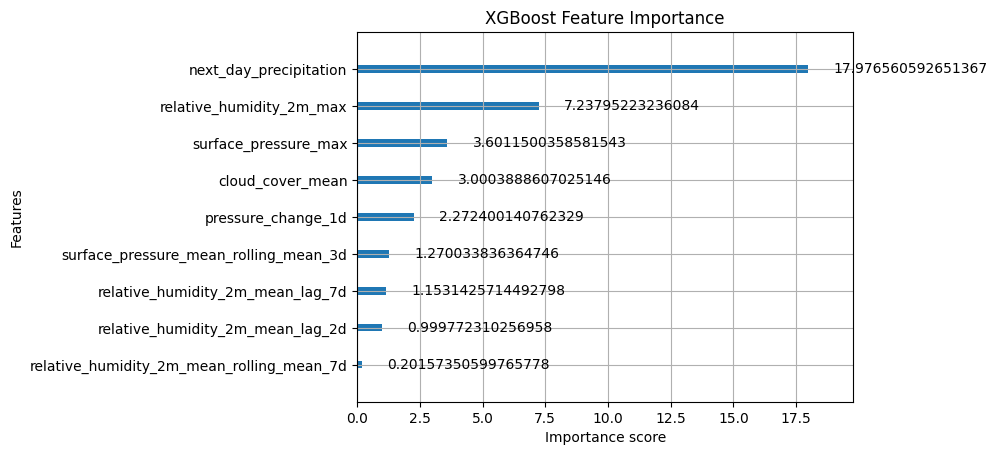

In [47]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

import matplotlib.pyplot as plt

xgb.plot_importance(
    xgb_model,
    max_num_features=20,
    importance_type="gain"
)

plt.title("XGBoost Feature Importance")
plt.show()

In [48]:
# ============================================================
# NEXT DAY PREDICTION
# ============================================================

# Az utolsó rendelkezésre álló observation
# feature-jeit használjuk.

X_today = X.iloc[[-1]]


# Eső valószínűsége
tomorrow_probability = (
    xgb_model.predict_proba(X_today)[0, 1]
)


# Százalék
tomorrow_probability_percent = tomorrow_probability * 100


print(
    f"🌧️ A következő nap eső valószínűsége: "
    f"{tomorrow_probability_percent:.1f}%"
)

🌧️ A következő nap eső valószínűsége: 8.0%


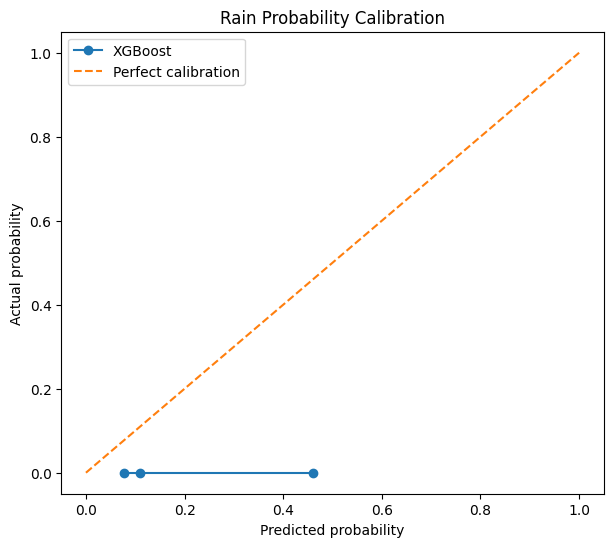

In [49]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob,
    n_bins=10
)

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Predicted probability")
plt.ylabel("Actual probability")
plt.title("Rain Probability Calibration")
plt.legend()
plt.show()